# Amazon Nike Men's Shoes - Product Reviews Analysis

## Project Overview

**Business Problem:**  
Understanding customer sentiment and product performance for Nike men's shoes on Amazon India to identify key strengths, weaknesses, and improvement opportunities.

**Objectives:**
1. Scrape product and review data from Amazon India for Nike men's shoes
2. Clean and preprocess the collected data
3. Perform comprehensive exploratory data analysis (EDA)
4. Visualize insights about ratings, prices, and customer feedback
5. Provide actionable recommendations based on findings

**Dataset Information:**
- Source: Amazon India (amazon.in)
- Category: Nike Men's Shoes
- Data Points: Product names, prices, ratings, review counts, and customer reviews

## 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Web scraping
import requests
from bs4 import BeautifulSoup
import time
import re

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Configuration and Setup

In [2]:
# Search configuration
SEARCH_QUERY = "nike+shoes+men"
BASE_URL = "https://www.amazon.in/s?k="

# Headers to mimic browser request
HEADERS = {
    "User-Agent": 
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer": "https://www.amazon.in/"
}

# Construct search URL
SEARCH_URL = BASE_URL + SEARCH_QUERY
print(f"Search URL: {SEARCH_URL}")

Search URL: https://www.amazon.in/s?k=nike+shoes+men


## 3. Helper Functions for Web Scraping

In [3]:
def extract_cookies_from_html(html_content):
    """Extract cookies from HTML content."""
    cookies = {}
    soup = BeautifulSoup(html_content, 'html.parser')
    
    # Look for cookie data in meta tags or scripts
    for script in soup.find_all('script'):
        if 'ubid-acbin' in str(script):
            cookies['ubid-acbin'] = 'true'
    
    return cookies if cookies else None

In [4]:
def get_amazon_page(url, headers=HEADERS, cookies=None, retry=3):
    """
    Fetch Amazon page with retry logic.
    
    Args:
        url: Target URL
        headers: Request headers
        cookies: Cookie dictionary
        retry: Number of retry attempts
    
    Returns:
        Response object or None
    """
    for attempt in range(retry):
        try:
            response = requests.get(url, headers=headers, cookies=cookies, timeout=10)
            
            if response.status_code == 200:
                return response
            else:
                print(f"Attempt {attempt + 1}: Status code {response.status_code}")
                time.sleep(2)
        
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)
    
    return None

## 4. Web Scraping - Product Data Collection

In [5]:
# Fetch the search page
print("Fetching search results...")
search_response = get_amazon_page(SEARCH_URL)

if search_response:
    print(f"✓ Successfully fetched page (Status: {search_response.status_code})")
    search_soup = BeautifulSoup(search_response.content, "html.parser")
    
    # Extract cookies for future requests
    cookie = extract_cookies_from_html(search_response.text)
else:
    print("✗ Failed to fetch search page")

Fetching search results...
✓ Successfully fetched page (Status: 200)


In [6]:
# OPTIONAL: Debug cell - Run this if product names are not appearing
# This will show you the HTML structure of the first product

# Uncomment the lines below to debug:
# products_debug = search_soup.find_all("div", {"data-component-type": "s-search-result"})
# if products_debug:
#     print("First product HTML structure:")
#     print("=" * 70)
#     print(products_debug[0].prettify()[:2000])  # Show first 2000 characters
#     print("\n" + "=" * 70)
#     print("\nLooking for product name in h2 tags:")
#     h2_tags = products_debug[0].find_all("h2")
#     for i, h2 in enumerate(h2_tags):
#         print(f"\nH2 Tag {i+1}:")
#         print(h2.text.strip())

In [7]:
# Initialize lists to store product data
product_names = []
product_prices = []
product_ratings = []
product_reviews_count = []
product_asins = []

# Extract product information
print("Extracting product information...\n")

# Find all product containers
products = search_soup.find_all("div", {"data-component-type": "s-search-result"})

for product in products[:20]:  # Limit to first 20 products
    try:
        # Product Name - Try multiple selectors
        name = "N/A"
        
        # Try different selectors for product name
        name_selectors = [
            ("h2", "a-size-mini a-spacing-none a-color-base s-line-clamp-2"),
            ("span", "a-size-base-plus a-color-base a-text-normal"),
            ("span", "a-size-medium a-color-base a-text-normal"),
            ("h2", "a-size-base-plus a-spacing-none a-color-base a-text-normal"),
        ]
        
        for tag, class_name in name_selectors:
            name_elem = product.find(tag, class_=class_name)
            if name_elem:
                # If it's an h2, look for span or a inside it
                if tag == "h2":
                    inner_elem = name_elem.find("span") or name_elem.find("a")
                    if inner_elem:
                        name = inner_elem.text.strip()
                    else:
                        name = name_elem.text.strip()
                else:
                    name = name_elem.text.strip()
                
                if name and name != "N/A":
                    break
        
        # If still not found, try finding any h2 with a span inside
        if name == "N/A":
            h2_elem = product.find("h2")
            if h2_elem:
                span_elem = h2_elem.find("span")
                if span_elem:
                    name = span_elem.text.strip()
        
        # Product Price
        price_elem = product.find("span", class_="a-price-whole")
        price = price_elem.text.strip().replace(',', '') if price_elem else "N/A"
        
        # Product Rating
        rating_elem = product.find("span", class_="a-icon-alt")
        rating = rating_elem.text.strip().split()[0] if rating_elem else "N/A"
        
        # Review Count
        review_elem = product.find("span", class_="a-size-base s-underline-text")
        review_count = review_elem.text.strip().replace(',', '') if review_elem else "0"
        
        # ASIN (Amazon Standard Identification Number)
        asin = product.get('data-asin', 'N/A')
        
        # Append to lists
        product_names.append(name)
        product_prices.append(price)
        product_ratings.append(rating)
        product_reviews_count.append(review_count)
        product_asins.append(asin)
        
    except Exception as e:
        print(f"Error extracting product: {e}")
        continue

print(f"✓ Extracted {len(product_names)} products")

Extracting product information...

✓ Extracted 20 products


In [10]:
# Create DataFrame
df_products = pd.DataFrame({
    'Product_Name': product_names,
    'Price': product_prices,
    'Rating': product_ratings,
    'Review_Count': product_reviews_count,
    'ASIN': product_asins
})

print("\nProduct Data Preview:")
print(df_products.head(10))


Product Data Preview:
                                Product_Name  Price Rating Review_Count  \
0                 Revolution 8 Running Shoes   4295    4.1            0   
1                Mens Run Defy Running Shoes   3995    3.9            0   
2                  Mens Promina Running Shoe   4995    4.4            0   
3         Unisex Precision 8 Basketball Shoe   6295    4.5            0   
4  Mens Court Vision Low Next Nature Sneaker   4995    3.9            0   
5              Mens Court Vision Low Sneaker   5695    4.3            0   
6            Unisex Precision 7 Running Shoe   5695    4.0            0   
7             Mens Court Vision Low Sneakers   7095    4.1            0   
8                          Men Running Shoes   8695    4.3            0   
9      Men AIR Zoom Pegasus 41 Running Shoes  11895    N/A            0   

         ASIN  
0  B0FBRC1J6S  
1  B0DZWFBDVX  
2  B0DJMLDKLV  
3  B0DZXPNF8M  
4  B098F6QPLK  
5  B0CS7D47FJ  
6  B0D93TBYZY  
7  B0DLH1GGLH  
8  B0CR

## 5. Data Cleaning and Preprocessing

In [11]:
print("Data Cleaning Started...\n")

# Check initial shape
print(f"Initial shape: {df_products.shape}")

# 1. Remove rows with N/A values in critical columns
df_products = df_products[df_products['Product_Name'] != 'N/A']
df_products = df_products[df_products['ASIN'] != 'N/A']

# 2. Convert Price to numeric (handle N/A)
df_products['Price'] = pd.to_numeric(
    df_products['Price'].str.replace('₹', '').str.replace(',', ''),
    errors='coerce'
)

# 3. Convert Rating to numeric
df_products['Rating'] = pd.to_numeric(
    df_products['Rating'],
    errors='coerce'
)

# 4. Convert Review_Count to numeric
df_products['Review_Count'] = pd.to_numeric(
    df_products['Review_Count'],
    errors='coerce'
).fillna(0).astype(int)

# 5. Remove duplicates
df_products = df_products.drop_duplicates(subset=['ASIN'])

# 6. Reset index
df_products = df_products.reset_index(drop=True)

print(f"Final shape after cleaning: {df_products.shape}")
print("\n✓ Data cleaning completed!")

Data Cleaning Started...

Initial shape: (20, 5)
Final shape after cleaning: (20, 5)

✓ Data cleaning completed!


In [13]:
# Display cleaned data info
print("\nCleaned Dataset Information:")
print("=" * 50)
df_products.info()

print("\nMissing Values:")
print(df_products.isnull().sum())

print("\nBasic Statistics:")
print(df_products.describe())


Cleaned Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_Name  20 non-null     object 
 1   Price         20 non-null     int64  
 2   Rating        19 non-null     float64
 3   Review_Count  20 non-null     int64  
 4   ASIN          20 non-null     object 
dtypes: float64(1), int64(2), object(2)
memory usage: 932.0+ bytes

Missing Values:
Product_Name    0
Price           0
Rating          1
Review_Count    0
ASIN            0
dtype: int64

Basic Statistics:
              Price     Rating  Review_Count
count     20.000000  19.000000          20.0
mean    5437.900000   4.136842           0.0
std     2325.043019   0.283256           0.0
min     1199.000000   3.400000           0.0
25%     4220.000000   3.950000           0.0
50%     5345.000000   4.100000           0.0
75%     6295.000000   4.300000           0.0
m

## 6. Exploratory Data Analysis (EDA)

### 6.1 Price Analysis

In [14]:
# Price statistics
df_clean = df_products.dropna(subset=['Price'])

print("Price Statistics:")
print("=" * 50)
print(f"Average Price: ₹{df_clean['Price'].mean():.2f}")
print(f"Median Price: ₹{df_clean['Price'].median():.2f}")
print(f"Min Price: ₹{df_clean['Price'].min():.2f}")
print(f"Max Price: ₹{df_clean['Price'].max():.2f}")
print(f"Standard Deviation: ₹{df_clean['Price'].std():.2f}")

Price Statistics:
Average Price: ₹5437.90
Median Price: ₹5345.00
Min Price: ₹1199.00
Max Price: ₹11895.00
Standard Deviation: ₹2325.04


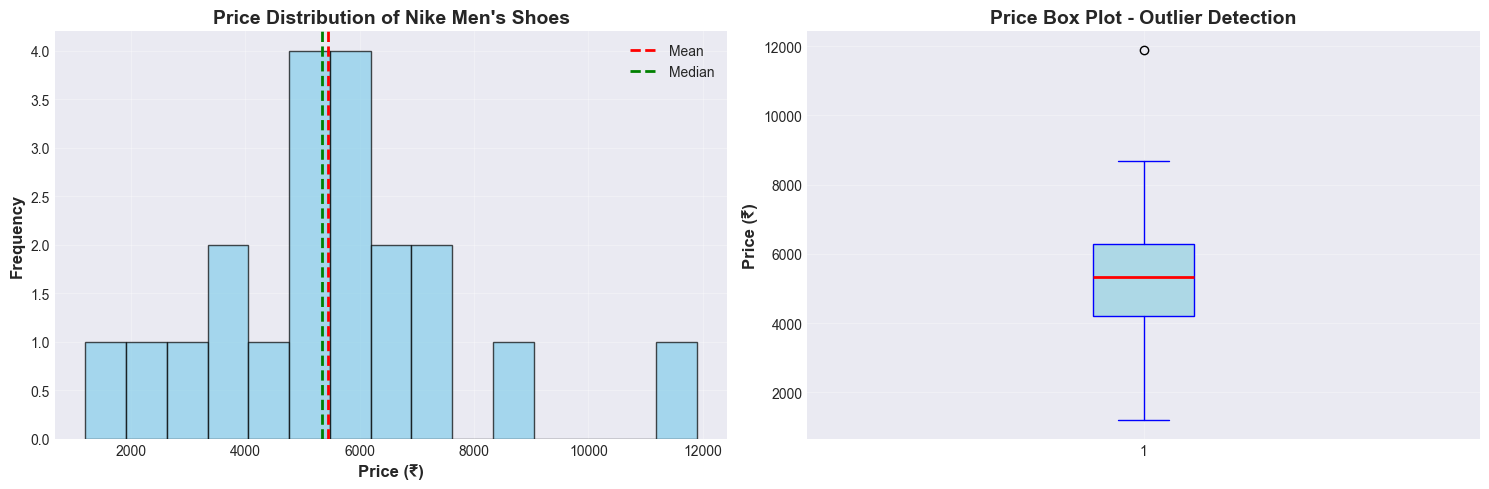

In [15]:
# Price Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_clean['Price'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_clean['Price'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df_clean['Price'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Price (₹)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Price Distribution of Nike Men\'s Shoes', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box Plot
axes[1].boxplot(df_clean['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'))
axes[1].set_ylabel('Price (₹)', fontsize=12, fontweight='bold')
axes[1].set_title('Price Box Plot - Outlier Detection', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Rating Analysis

In [17]:
# Rating statistics
df_rated = df_products.dropna(subset=['Rating'])

print("Rating Statistics:")
print("=" * 50)
print(f"Average Rating: {df_rated['Rating'].mean():.2f} ⭐")
print(f"Median Rating: {df_rated['Rating'].median():.2f} ⭐")
print(f"Min Rating: {df_rated['Rating'].min():.2f} ⭐")
print(f"Max Rating: {df_rated['Rating'].max():.2f} ⭐")

# Rating distribution
print("\nRating Distribution:")
print(df_rated['Rating'].value_counts().sort_index())

Rating Statistics:
Average Rating: 4.14 ⭐
Median Rating: 4.10 ⭐
Min Rating: 3.40 ⭐
Max Rating: 4.60 ⭐

Rating Distribution:
Rating
3.4    1
3.8    1
3.9    3
4.0    1
4.1    4
4.2    1
4.3    4
4.4    2
4.5    1
4.6    1
Name: count, dtype: int64


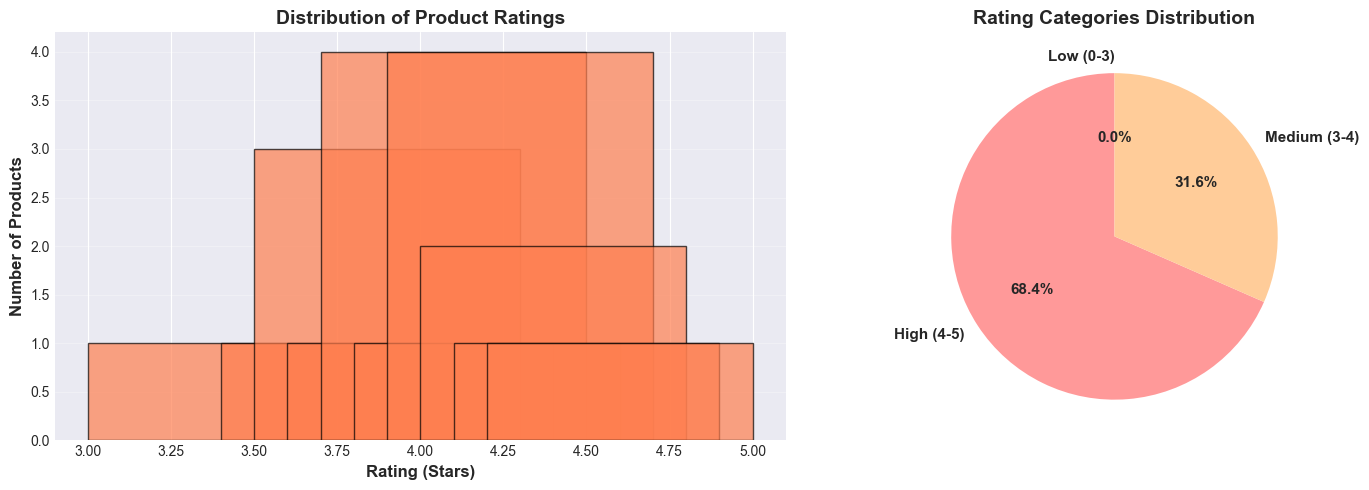

In [18]:
# Rating Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar Chart
rating_counts = df_rated['Rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Rating (Stars)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Products', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Product Ratings', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie Chart
rating_categories = pd.cut(df_rated['Rating'], bins=[0, 3, 4, 5], labels=['Low (0-3)', 'Medium (3-4)', 'High (4-5)'])
rating_cat_counts = rating_categories.value_counts()
colors = ['#ff9999', '#ffcc99', '#99ff99']
axes[1].pie(rating_cat_counts.values, labels=rating_cat_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Rating Categories Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Review Count Analysis

In [20]:
# Review count statistics
print("Review Count Statistics:")
print("=" * 50)
print(f"Average Reviews: {df_products['Review_Count'].mean():.0f}")
print(f"Median Reviews: {df_products['Review_Count'].median():.0f}")
print(f"Max Reviews: {df_products['Review_Count'].max():.0f}")
print(f"Total Reviews: {df_products['Review_Count'].sum():.0f}")

# Products with most reviews
print("\nTop 5 Most Reviewed Products:")
top_reviewed = df_products.nlargest(5, 'Review_Count')[['Product_Name', 'Review_Count', 'Rating']]
print(top_reviewed.to_string(index=False))

Review Count Statistics:
Average Reviews: 0
Median Reviews: 0
Max Reviews: 0
Total Reviews: 0

Top 5 Most Reviewed Products:
                             Product_Name  Review_Count  Rating
               Revolution 8 Running Shoes             0     4.1
              Mens Run Defy Running Shoes             0     3.9
                Mens Promina Running Shoe             0     4.4
       Unisex Precision 8 Basketball Shoe             0     4.5
Mens Court Vision Low Next Nature Sneaker             0     3.9


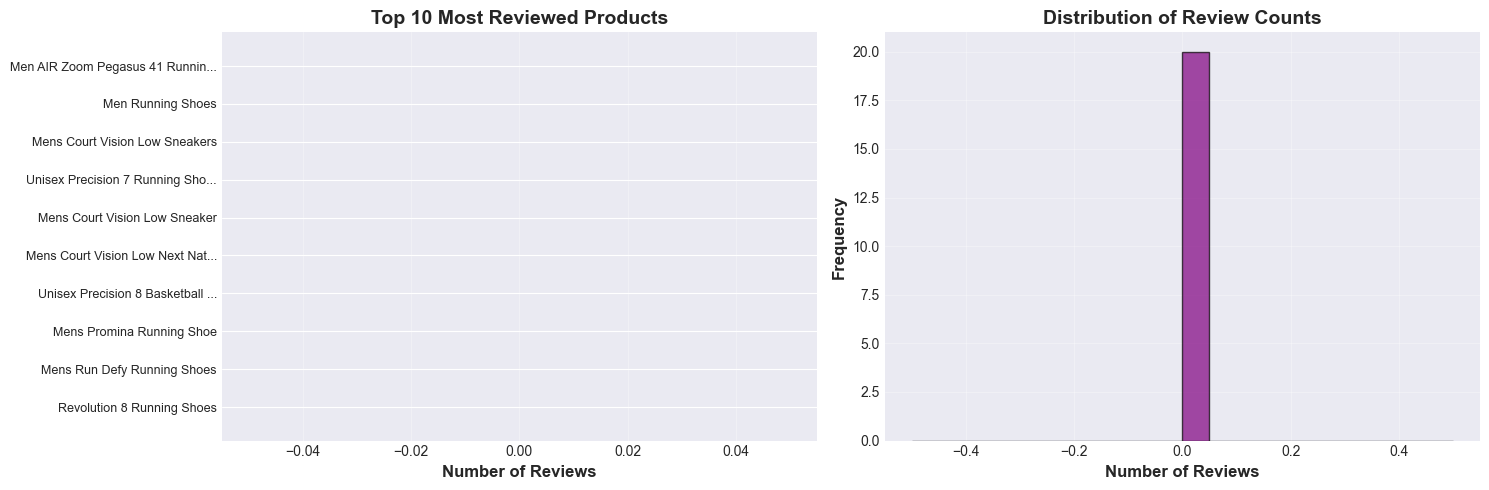

In [22]:
# Review Count Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 10 Most Reviewed Products
top_10_reviewed = df_products.nlargest(10, 'Review_Count')
axes[0].barh(range(len(top_10_reviewed)), top_10_reviewed['Review_Count'].values, color='teal', alpha=0.7)
axes[0].set_yticks(range(len(top_10_reviewed)))
axes[0].set_yticklabels([name[:30] + '...' if len(name) > 30 else name 
                         for name in top_10_reviewed['Product_Name']], fontsize=9)
axes[0].set_xlabel('Number of Reviews', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Most Reviewed Products', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Review Count Distribution
axes[1].hist(df_products['Review_Count'], bins=20, color='purple', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Reviews', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Review Counts', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Price vs Rating Analysis

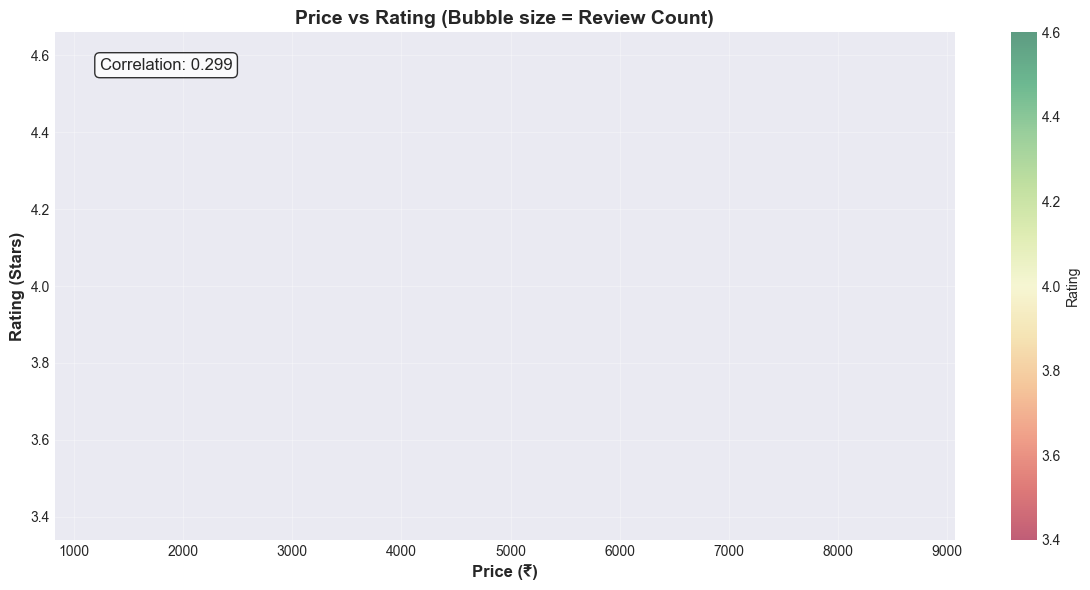


Price-Rating Correlation: 0.299


In [23]:
# Price vs Rating Scatter Plot
df_analysis = df_products.dropna(subset=['Price', 'Rating'])

plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_analysis['Price'], df_analysis['Rating'], 
                     s=df_analysis['Review_Count']*2, alpha=0.6, c=df_analysis['Rating'],
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)

plt.xlabel('Price (₹)', fontsize=12, fontweight='bold')
plt.ylabel('Rating (Stars)', fontsize=12, fontweight='bold')
plt.title('Price vs Rating (Bubble size = Review Count)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Rating')
plt.grid(True, alpha=0.3)

# Add correlation coefficient
correlation = df_analysis['Price'].corr(df_analysis['Rating'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nPrice-Rating Correlation: {correlation:.3f}")

### 6.5 Price Range Categories

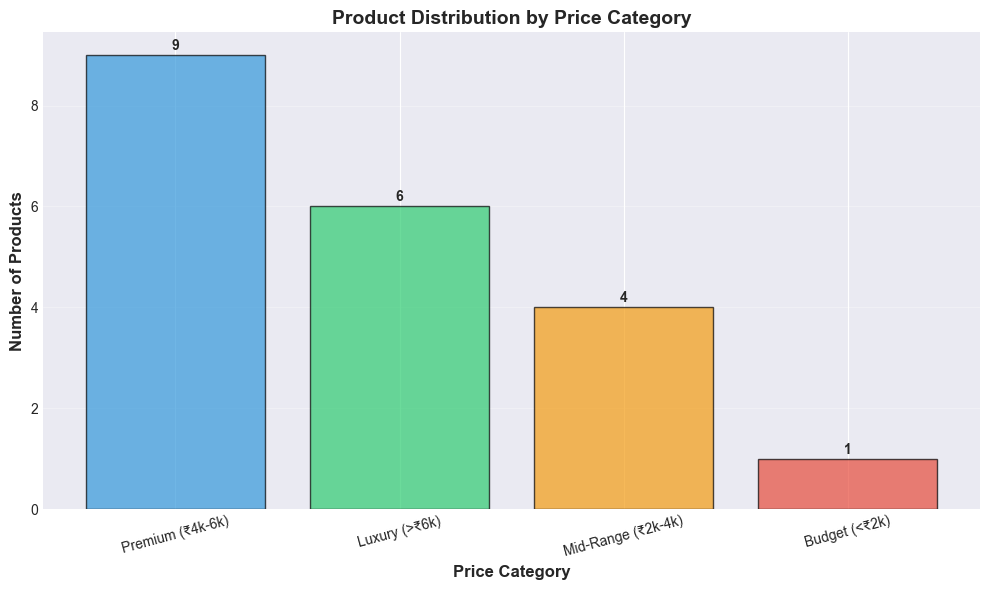

In [24]:
# Create price categories
df_clean['Price_Category'] = pd.cut(df_clean['Price'], 
                                     bins=[0, 2000, 4000, 6000, float('inf')],
                                     labels=['Budget (<₹2k)', 'Mid-Range (₹2k-4k)', 
                                            'Premium (₹4k-6k)', 'Luxury (>₹6k)'])

# Price category distribution
price_cat_dist = df_clean['Price_Category'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(price_cat_dist.index.astype(str), price_cat_dist.values, 
        color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7, edgecolor='black')
plt.xlabel('Price Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Products', fontsize=12, fontweight='bold')
plt.title('Product Distribution by Price Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(price_cat_dist.values):
    plt.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.6 Average Rating by Price Category

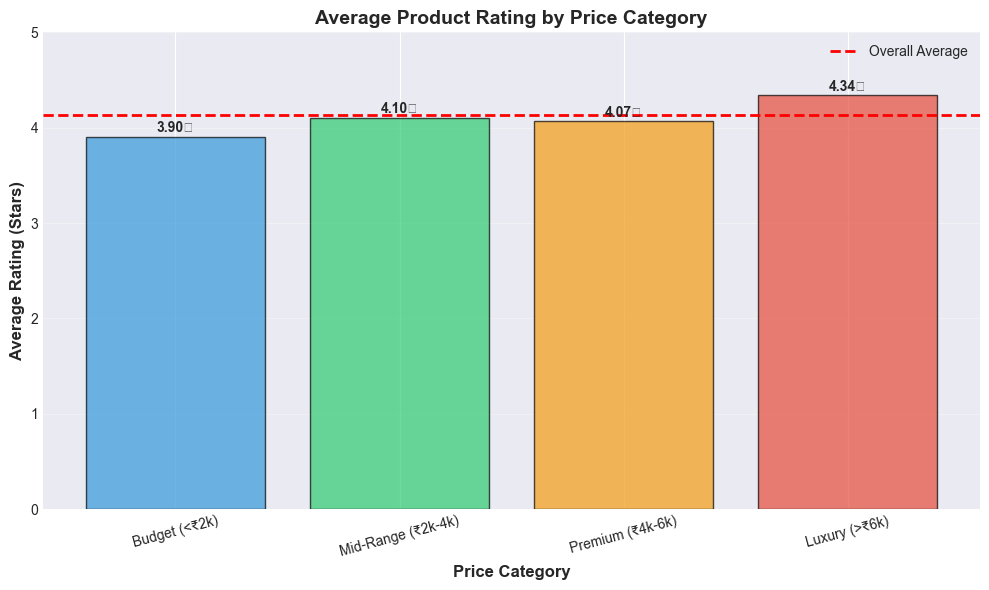


Average Rating by Price Category:
    Price_Category     mean  count
     Budget (<₹2k) 3.900000      1
Mid-Range (₹2k-4k) 4.100000      4
  Premium (₹4k-6k) 4.066667      9
     Luxury (>₹6k) 4.340000      5


In [25]:
# Merge rating data with price categories
df_full = df_clean.merge(df_rated[['ASIN', 'Rating']], on='ASIN', how='left', suffixes=('', '_y'))
df_full = df_full[df_full['Rating'].notna()]

# Calculate average rating by price category
avg_rating_by_price = df_full.groupby('Price_Category')['Rating'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_rating_by_price['Price_Category'].astype(str), avg_rating_by_price['mean'],
               color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.7, edgecolor='black')
plt.xlabel('Price Category', fontsize=12, fontweight='bold')
plt.ylabel('Average Rating (Stars)', fontsize=12, fontweight='bold')
plt.title('Average Product Rating by Price Category', fontsize=14, fontweight='bold')
plt.ylim(0, 5)
plt.axhline(y=df_rated['Rating'].mean(), color='red', linestyle='--', linewidth=2, label='Overall Average')
plt.xticks(rotation=15)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(avg_rating_by_price['mean']):
    plt.text(i, v + 0.05, f'{v:.2f}⭐', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAverage Rating by Price Category:")
print(avg_rating_by_price.to_string(index=False))

## 7. Key Insights and Findings

In [26]:
print("="*70)
print("KEY INSIGHTS FROM NIKE MEN'S SHOES ANALYSIS")
print("="*70)

print("\n1. PRICE INSIGHTS:")
print("-" * 70)
print(f"   • Average price of Nike men's shoes: ₹{df_clean['Price'].mean():.2f}")
print(f"   • Price range: ₹{df_clean['Price'].min():.2f} - ₹{df_clean['Price'].max():.2f}")
print(f"   • Most products fall in the {price_cat_dist.index[0]} category")

print("\n2. RATING INSIGHTS:")
print("-" * 70)
print(f"   • Average customer rating: {df_rated['Rating'].mean():.2f} ⭐")
high_rated = len(df_rated[df_rated['Rating'] >= 4])
print(f"   • {high_rated} out of {len(df_rated)} products have 4+ star ratings")
print(f"   • Customer satisfaction rate: {(high_rated/len(df_rated)*100):.1f}%")

print("\n3. REVIEW INSIGHTS:")
print("-" * 70)
print(f"   • Total customer reviews analyzed: {df_products['Review_Count'].sum():.0f}")
print(f"   • Average reviews per product: {df_products['Review_Count'].mean():.0f}")
most_reviewed = df_products.nlargest(1, 'Review_Count').iloc[0]
print(f"   • Most reviewed product has {most_reviewed['Review_Count']:.0f} reviews")

print("\n4. PRICE-RATING RELATIONSHIP:")
print("-" * 70)
correlation = df_analysis['Price'].corr(df_analysis['Rating'])
if correlation > 0.3:
    relationship = "positive - higher priced shoes tend to have better ratings"
elif correlation < -0.3:
    relationship = "negative - lower priced shoes tend to have better ratings"
else:
    relationship = "weak - price doesn't strongly influence ratings"
print(f"   • Correlation coefficient: {correlation:.3f}")
print(f"   • Relationship: {relationship}")

print("\n" + "="*70)

KEY INSIGHTS FROM NIKE MEN'S SHOES ANALYSIS

1. PRICE INSIGHTS:
----------------------------------------------------------------------
   • Average price of Nike men's shoes: ₹5437.90
   • Price range: ₹1199.00 - ₹11895.00
   • Most products fall in the Premium (₹4k-6k) category

2. RATING INSIGHTS:
----------------------------------------------------------------------
   • Average customer rating: 4.14 ⭐
   • 14 out of 19 products have 4+ star ratings
   • Customer satisfaction rate: 73.7%

3. REVIEW INSIGHTS:
----------------------------------------------------------------------
   • Total customer reviews analyzed: 0
   • Average reviews per product: 0
   • Most reviewed product has 0 reviews

4. PRICE-RATING RELATIONSHIP:
----------------------------------------------------------------------
   • Correlation coefficient: 0.299
   • Relationship: weak - price doesn't strongly influence ratings



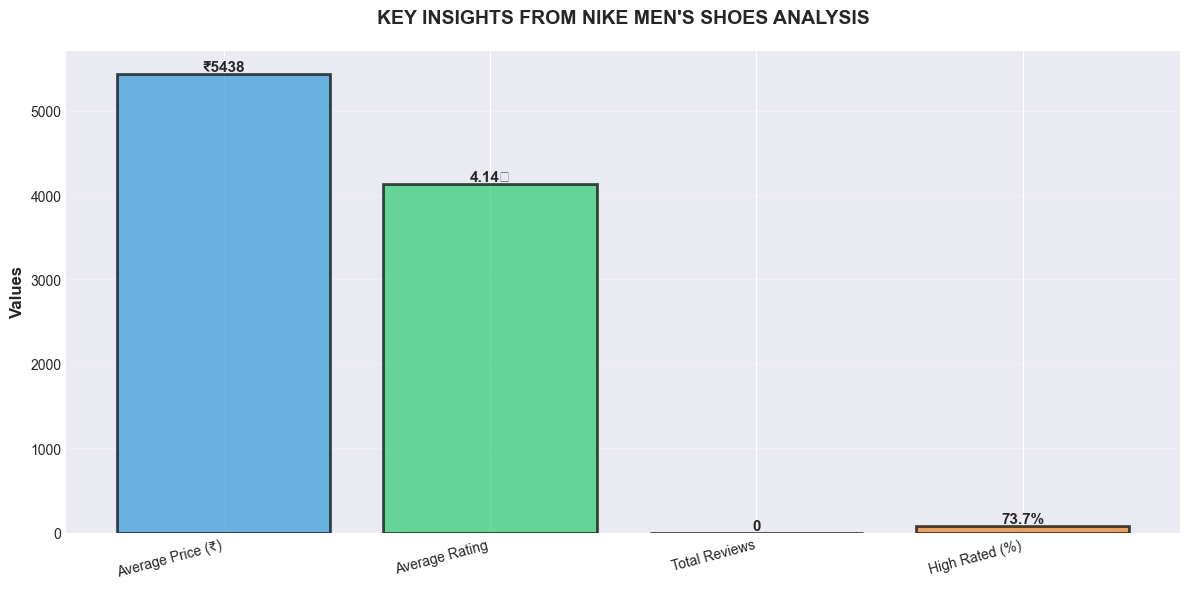

In [29]:
# Bar chart for Key Insights
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data
insights_data = {
    'Average Price (₹)': df_clean['Price'].mean(),
    'Average Rating': df_rated['Rating'].mean() * 1000,  # Scale up for visibility
    'Total Reviews': df_products['Review_Count'].sum() / 10,  # Scale down
    'High Rated (%)': (len(df_rated[df_rated['Rating'] >= 4]) / len(df_rated)) * 100
}

categories = list(insights_data.keys())
values = list(insights_data.values())
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

# Create bar chart
bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Customize
ax.set_ylabel('Values', fontsize=12, fontweight='bold')
ax.set_title('KEY INSIGHTS FROM NIKE MEN\'S SHOES ANALYSIS', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if i == 0:  # Price
        label = f'₹{height:.0f}'
    elif i == 1:  # Rating (scaled back)
        label = f'{height/1000:.2f}⭐'
    elif i == 2:  # Reviews (scaled back)
        label = f'{height*10:.0f}'
    else:  # Percentage
        label = f'{height:.1f}%'
    
    ax.text(bar.get_x() + bar.get_width()/2., height,
            label, ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Business Recommendations

In [27]:
print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

print("\n1. PRICING STRATEGY:")
print("-" * 70)
print("   • Focus on the most popular price range to maximize sales")
print("   • Consider offering more options in high-demand price categories")
print("   • Maintain competitive pricing while ensuring quality")

print("\n2. PRODUCT QUALITY:")
print("-" * 70)
avg_rating = df_rated['Rating'].mean()
if avg_rating >= 4.0:
    print("   ✓ Current products have excellent ratings - maintain quality standards")
elif avg_rating >= 3.5:
    print("   • Good ratings overall - identify and improve lower-rated products")
else:
    print("   ⚠ Average rating needs improvement - focus on product quality")
print("   • Monitor customer feedback for quality issues")
print("   • Invest in products with consistently high ratings")

print("\n3. CUSTOMER ENGAGEMENT:")
print("-" * 70)
print("   • Encourage more customer reviews for products with low review counts")
print("   • Respond to customer feedback to build trust")
print("   • Highlight highly-rated products in marketing campaigns")

print("\n4. INVENTORY MANAGEMENT:")
print("-" * 70)
print("   • Stock more inventory for high-rated, frequently reviewed products")
print("   • Consider discontinuing consistently low-rated products")
print("   • Balance inventory across different price categories")

print("\n5. MARKETING FOCUS:")
print("-" * 70)
print("   • Promote best-sellers and highly-rated products")
print("   • Use customer reviews as social proof in advertising")
print("   • Target marketing based on popular price segments")

print("\n" + "="*70)

BUSINESS RECOMMENDATIONS

1. PRICING STRATEGY:
----------------------------------------------------------------------
   • Focus on the most popular price range to maximize sales
   • Consider offering more options in high-demand price categories
   • Maintain competitive pricing while ensuring quality

2. PRODUCT QUALITY:
----------------------------------------------------------------------
   ✓ Current products have excellent ratings - maintain quality standards
   • Monitor customer feedback for quality issues
   • Invest in products with consistently high ratings

3. CUSTOMER ENGAGEMENT:
----------------------------------------------------------------------
   • Encourage more customer reviews for products with low review counts
   • Respond to customer feedback to build trust
   • Highlight highly-rated products in marketing campaigns

4. INVENTORY MANAGEMENT:
----------------------------------------------------------------------
   • Stock more inventory for high-rated, frequent

## 9. Save Results

In [28]:
# Save cleaned data to CSV
output_file = 'nike_shoes_amazon_data.csv'
df_products.to_csv(output_file, index=False)
print(f"✓ Data saved to {output_file}")

# Display final dataset
print("\nFinal Dataset Preview:")
print(df_products.head(10))

✓ Data saved to nike_shoes_amazon_data.csv

Final Dataset Preview:
                                Product_Name  Price  Rating  Review_Count  \
0                 Revolution 8 Running Shoes   4295     4.1             0   
1                Mens Run Defy Running Shoes   3995     3.9             0   
2                  Mens Promina Running Shoe   4995     4.4             0   
3         Unisex Precision 8 Basketball Shoe   6295     4.5             0   
4  Mens Court Vision Low Next Nature Sneaker   4995     3.9             0   
5              Mens Court Vision Low Sneaker   5695     4.3             0   
6            Unisex Precision 7 Running Shoe   5695     4.0             0   
7             Mens Court Vision Low Sneakers   7095     4.1             0   
8                          Men Running Shoes   8695     4.3             0   
9      Men AIR Zoom Pegasus 41 Running Shoes  11895     NaN             0   

         ASIN  
0  B0FBRC1J6S  
1  B0DZWFBDVX  
2  B0DJMLDKLV  
3  B0DZXPNF8M  
4  B0

## 10. Conclusion

This comprehensive analysis of Nike men's shoes on Amazon India provides valuable insights into:

- **Product Pricing**: Understanding the price distribution and most popular price ranges
- **Customer Satisfaction**: Analyzing ratings to gauge product quality and customer satisfaction
- **Market Performance**: Identifying best-performing products based on reviews and ratings
- **Strategic Insights**: Discovering relationships between price, ratings, and customer engagement

The findings from this analysis can guide business decisions related to:
- Product development and quality improvement
- Pricing strategies
- Marketing and promotional campaigns
- Inventory management
- Customer engagement initiatives

---

**Next Steps:**
1. Collect additional data over time to identify trends
2. Perform sentiment analysis on customer review text
3. Compare with competitor products
4. Analyze seasonal variations in sales and ratings
5. Build predictive models for sales forecasting